In [ ]:
#this script is meant to test the prediction level throughout the conversation (each time insert a conversation with more and more of its messages and see how the prediction value changes)
import pandas as pd
import numpy as np
from tqdm import tqdm_pandas
from tqdm.notebook import tqdm
from transformers import BertModel, BertTokenizerFast, Trainer, TrainingArguments, AutoModelForSequenceClassification, AutoTokenizer, BertForSequenceClassification, BertTokenizer
import torch
from datasets import Dataset
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_recall_fscore_support,  roc_auc_score, fbeta_score
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
import torch.nn as nn
import warnings
warnings.filterwarnings("ignore")



model_name = 'onlplab/alephbert-base'
tokenizer = AutoTokenizer.from_pretrained(model_name)
bert_model = AutoModelForSequenceClassification.from_pretrained(model_name , num_labels=2)

checkpoint_path = "models/model_weights_progressive_curiculum_learning_conv_messages.pth"

# Load state dict
state_dict = torch.load(checkpoint_path, map_location="cpu")  # or "cuda" if on GPU

# Load weights into model
bert_model.load_state_dict(state_dict)

# Move to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bert_model.to(device)


/home/ronfr/.conda/envs/alephbert_eval/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at onlplab/alephbert-base and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(52000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [2]:
conv_info_path = 'trainDatasets/conv_info.csv'
conv_info_df = pd.read_csv(conv_info_path)
conv_info_df['engagement_id'] = conv_info_df['engagement_id'].astype(str)
conv_info_df = conv_info_df.rename(columns={'gsr': 'label'})
train_conv_df, test_conv_df = train_test_split(conv_info_df, test_size=0.2, stratify=conv_info_df['label'],random_state=42)

In [3]:
all_messages_path = 'trainDatasets/messages_anonymized.csv'

all_messages_df = pd.read_csv(all_messages_path)
all_messages_df['engagement_id'] = all_messages_df['engagement_id'].astype(str)

In [10]:
test_conv_df_positive_sample = test_conv_df[test_conv_df["label"] == 1].sample(n=10, random_state=34)
test_conv_df_negative_sample = test_conv_df[test_conv_df["label"] == 0].sample(n=10, random_state=34)


In [13]:
import torch.nn.functional as F
prediction_dict = {}
tokenizer.truncation_side='left'
for id in test_conv_df_positive_sample["engagement_id"]:
    curr_messages = all_messages_df[(all_messages_df["engagement_id"] == id) & (all_messages_df["seeker"])]
    log = ""
    prob_list = []

    for message in curr_messages["anonymized"]:
        log += "[SEP]" + message  # or use "[SEP]" if your tokenizer/model is trained that way

        tokenized_log = tokenizer(
            log,
            padding='max_length',
            truncation=True,
            max_length=512,
            return_tensors="pt"
        )

        with torch.no_grad():
            output = bert_model(**tokenized_log)  # output.logits should contain class scores

        logits = output.logits  # shape: [1, num_classes]
        probs = F.softmax(logits, dim=-1)  # convert to probabilities
        positive_class_prob = probs[0, 1].item()  # get class 1 probability

        prob_list.append(positive_class_prob)

    prediction_dict[id] = prob_list

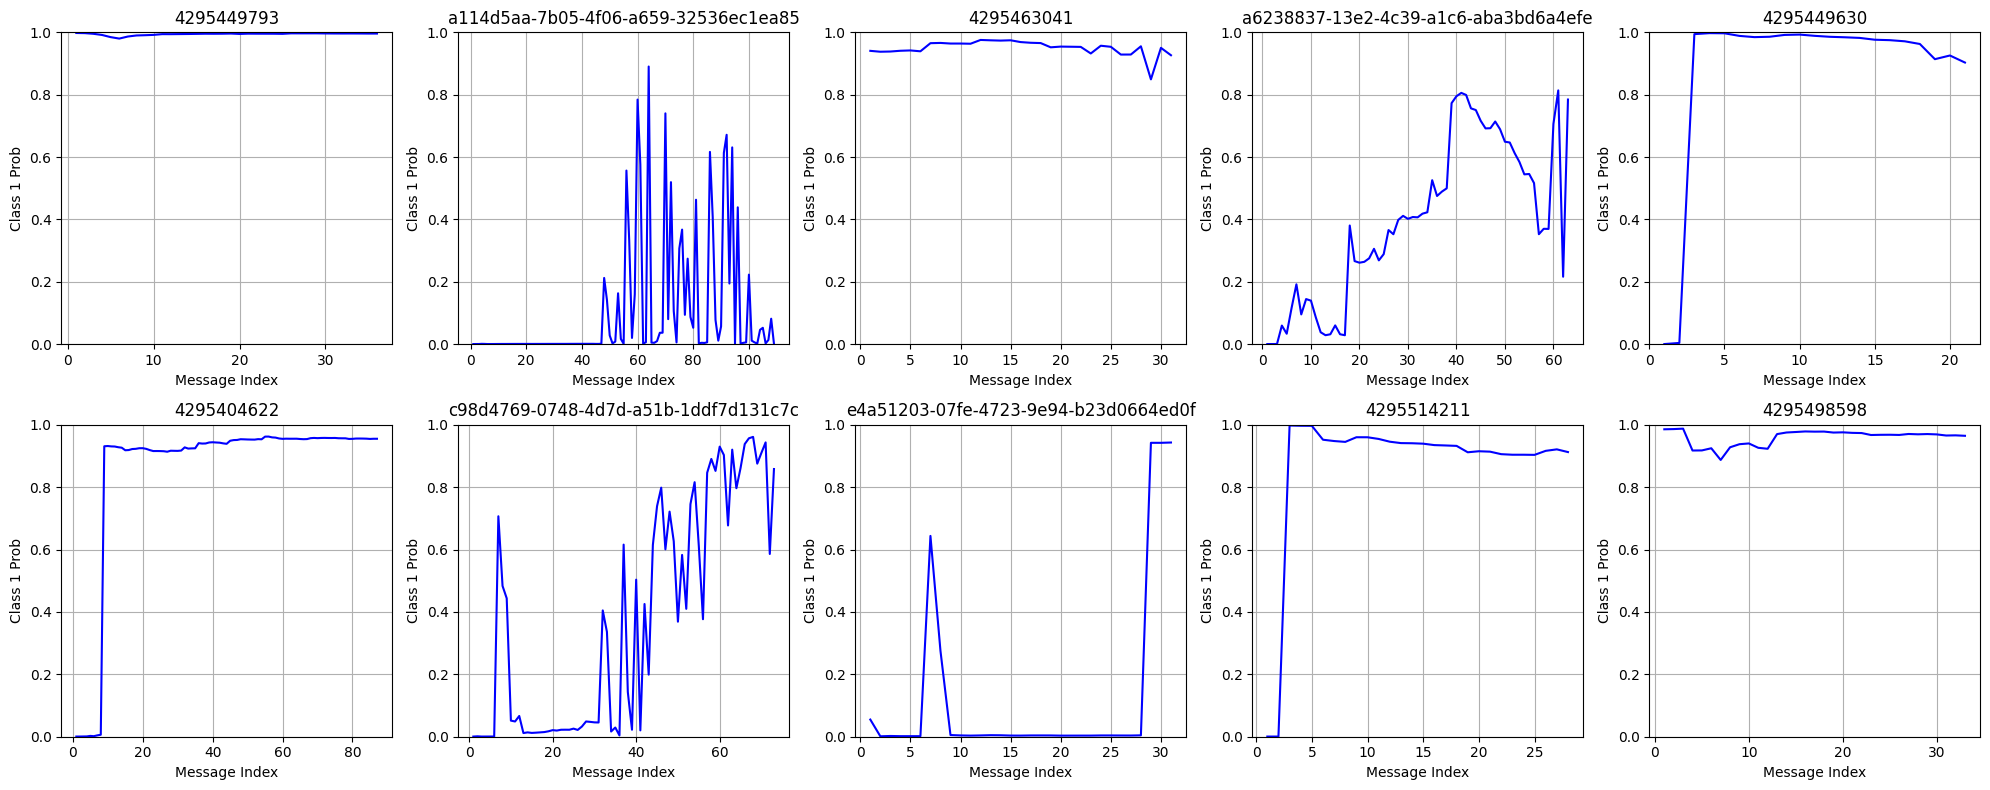

In [16]:
import matplotlib.pyplot as plt
import random


# Create subplots: 2 rows × 5 columns
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, engagement_id in enumerate(prediction_dict):
    probs = prediction_dict[engagement_id]
    ax = axes[i]
    ax.plot(range(1, len(probs) + 1), probs, color='blue')
    ax.set_title(f'{engagement_id}')
    ax.set_xlabel("Message Index")
    ax.set_ylabel("Class 1 Prob")
    ax.grid(True)
    ax.set_ylim(0, 1)  # Probabilities range from 0 to 1

plt.tight_layout()
plt.show()

In [9]:
test_conv_df_positive_sample

,engagement_id,date,name,gender,age,ved,label,imsr,subject_1,subject_2,subject_3,emergency_helpline,report_reason,helpline,referral_reason
2458,4295472700,2021-02-28,דניאל,אישה,14-17,2,1,0,דיכאון ועצבות קשה,NaN,NaN,NaN,NaN,NaN,NaN
15525,4295503781,2021-10-18,רות,אישה,14-17,-1,1,0,פציעה עצמית,דיכאון ועצבות קשה,NaN,NaN,NaN,NaN,NaN
28300,be564344-c728-42b4-a2ad-fb80229a2bd1,2023-07-19,call,גבר,31-40,-1,1,0,הפרעות נפשיות שונות,פציעה עצמית,ענייני זוגיות,מצודה,NaN,NaN,NaN
29313,2cf0e2ab-cc98-41ce-a756-5d12c6ef68e5,2023-08-20,דחוי,גבר,21-30,-1,1,1,בדידות,דיכאון ועצבות קשה,NaN,מצודה,NaN,NaN,NaN
14204,4295494368,2021-08-09,ע,אישה,31-40,2,1,0,טראומה מינית,בדידות,דיכאון ועצבות קשה,NaN,NaN,NaN,NaN
4005,4295463791,2021-01-04,פרפר,אישה,21-30,2,1,0,דיכאון ועצבות קשה,אי נגישות לטיפול,שיתופים והתייעצויות,NaN,NaN,NaN,NaN
1182,4295480129,2021-04-19,שיראל,אישה,14-17,4,1,0,שיתופים והתייעצויות,קשיים חברתיים,NaN,NaN,NaN,NaN,NaN
13608,4295497398,2021-08-30,מרוסקת,אישה,21-30,3,1,0,שכול ואובדן,בדידות,NaN,NaN,NaN,NaN,NaN
2495,4295472516,2021-02-27,מריה,אישה,14-17,3,1,0,קשיים משפחתיים,דיכאון ועצבות קשה,NaN,NaN,NaN,NaN,NaN
1658,4295477372,2021-03-30,דוד,גבר,31-40,3,1,1,דיכאון ועצבות קשה,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
all_messages_df[(all_messages_df["engagement_id"] == "4295403255") & (all_messages_df["seeker"])]["anonymized"].tolist()